# 🐧 Feature Engineering Adventure: Penguin Detective

---

## 🎯 Your Mission

Imagine you are a data scientist helping a team identify penguin species.

Your job is to teach a computer how to use penguin measurements and other information to make better predictions.

You will:

1. Explore the dataset 🔎
2. Find different kinds of features
3. Create **new features** from existing columns
4. Convert categorical information into numbers
5. Compare a model **before and after** feature engineering
6. Explain which features you think were most useful

> **Important:** You are not expected to get a perfect score. The goal is to experiment, learn, and explain your ideas.

## 🐧 About the Dataset

The Palmer Penguins dataset contains measurements of penguins observed in the Palmer Archipelago in Antarctica.

Each row represents one penguin.

Some useful columns include:

- `bill_length_mm` → length of the penguin's bill
- `bill_depth_mm` → depth of the bill
- `flipper_length_mm` → length of the flipper
- `body_mass_g` → body weight in grams
- `island` → island where the penguin was observed
- `sex` → recorded sex
- `year` → observation year
- `species` → penguin species (**our target**)

### 🎯 Target column

We will try to predict:

**`species`**

This is a **categorical target** because the answer is a category such as Adelie, Chinstrap, or Gentoo.


## 🧰 Step 1 — Import Our Tools


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## 📥 Step 2 — Load the Dataset

We will load the public Palmer Penguins dataset from GitHub.

### Your task

Run the cell and look at the first few rows.

Ask yourself:

- What does one row represent?

answer: about the penguins information

- Which columns contain numbers?

answer: bill_length_mm, bill_depth_mm, body_mass_g, year

- Which columns contain words?

answer: island, species, sex

- Which column is our target?

answer: species

In [24]:
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"

df = pd.read_csv(url)

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 🔎 Step 3 — Explore the Data

Before changing anything, become a **data detective**.

### Tasks

Run the cells below and answer these questions in the markdown cell:

1. How many rows are there?

answer: about the penguins information

2. How many columns are there?

answer: 9

3. Which columns contain missing values?

answer: sex, body_mass_g, bill_length_mm, bill_depth_mm, flipper_length_mm

4. What are the different penguin species?



5. Which columns look useful for predicting species?

In [25]:
# write down your code over here

print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nUnique species:')
print(df['species'].unique())

Number of rows: 344
Number of columns: 8

Missing values:
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Unique species:
['Adelie' 'Gentoo' 'Chinstrap']


### ✍️ Detective Notes

**1. Number of rows:**  
Your answer: `9`

**2. Number of columns:**  
Your answer: `9`

**3. Penguin species:**  
Your answer: `Adelie`

**4. One numeric feature I think will be useful:**  
Your answer: `False`

**5. One categorical feature I think will be useful:**  
Your answer: `False`

## 📊 Step 4 — Look at the Measurements

Let's see whether the penguins have different measurements.

### Your challenge

Look at the summary below.

Can you spot features where the values seem quite different between penguins?

In [26]:
# write code to see insight of numeric columns

df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [27]:
df.groupby("species")[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]].mean()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.504878,14.982114,217.186992,5076.016260


## 🧠 Think Like a Feature Engineer

Suppose you know:

- bill length
- bill depth
- flipper length
- body mass

Could we combine some of these numbers to create **new clues**?

Here are some ideas:

- `bill_ratio = bill_length / bill_depth`
- `body_mass_kg = body_mass_g / 1000`
- `flipper_cm = flipper_length_mm / 10`
- `bill_area_like = bill_length × bill_depth`

These are only examples.

### ⭐ Your mission

Create **at least 2 new features of your own**.

Try to make them meaningful rather than creating random numbers.

## 🛠️ Step 5 — Feature Engineering Experiment 1

### Create your first new feature

Create:

**`bill_ratio` = bill length ÷ bill depth**

Why might this be useful?

It gives us an idea of the **shape of the bill**, instead of looking at only one measurement.

In [28]:
df["bill_ratio"] = None # replace none with code

#corrected version
df["bill_ratio"] = df['bill_length_mm'] / df['bill_depth_mm']

#next steps
df[[
    "bill_length_mm",
    "bill_depth_mm",
    "bill_ratio",
    "species"
]].head()

,bill_length_mm,bill_depth_mm,bill_ratio,species
0,39.1,18.7,2.090909,Adelie
1,39.5,17.4,2.270115,Adelie
2,40.3,18.0,2.238889,Adelie
3,NaN,NaN,NaN,Adelie
4,36.7,19.3,1.901554,Adelie


## 🛠️ Step 6 — Feature Engineering Experiment 2

Create:

**`body_mass_kg` = body mass in grams ÷ 1000**

This does not add new information, but it changes the way the information is represented.

### Challenge

After creating it, compare the original and new columns.

In [29]:
df["body_mass_kg"] = df["body_mass_g"] / 1000
display(df[["body_mass_g", "body_mass_kg"]].head())

,body_mass_g,body_mass_kg
0,3750.0,3.75
1,3800.0,3.80
2,3250.0,3.25
3,NaN,NaN
4,3450.0,3.45


## 🧪 Step 7 — Your Own Feature

Now it is your turn!

Create **one new feature** using at least two existing numeric columns.

Ideas if you are stuck:

- `flipper_to_mass`
- `bill_size`
- `body_size_score`
- `bill_difference`
- `flipper_cm`

### Rules

✅ Use existing columns  
✅ Give your feature a meaningful name  
✅ Add a short comment explaining your idea  
❌ Do not use the target `species` to create the feature

In [30]:
# YOUR FEATURE NAME:
df["bill_difference"] = abs(df['bill_length_mm'] - df['bill_depth_mm'])

# Check your new feature:
display(df[["bill_length_mm", "bill_depth_mm", "bill_difference", "species"]].head())

,bill_length_mm,bill_depth_mm,bill_difference,species
0,39.1,18.7,20.4,Adelie
1,39.5,17.4,22.1,Adelie
2,40.3,18.0,22.3,Adelie
3,NaN,NaN,NaN,Adelie
4,36.7,19.3,17.4,Adelie


### 📝 Explain Your Feature

**My feature is called:** `bill_difference`

**I created it using:** `bill_length_mm` and `bill_depth_mm`

**My formula/idea is:** `abs(bill_length_mm - bill_depth_mm)`. It represents the absolute difference between the bill's length and depth.

**I think it could help because:**  
This feature might highlight extreme bill shapes. A large difference could indicate a very long and thin bill or a very short and deep bill, which could be distinctive characteristics for certain penguin species and their feeding habits. This could provide a different perspective compared to a simple ratio.

# 🤖 Step 8 — Build a Baseline Model

Before we use our engineered features, we need a **baseline**.

A baseline is our starting point.

We will train a Random Forest classifier using the original features.

### Why?

Later we can compare:

**Original features 🆚 Engineered features**

That comparison is the most important part of this activity.

In [31]:
# Remove rows where the target is missing
model_df = df.dropna(subset=["species"]).copy()

X = model_df.drop(columns=["species"])
y = model_df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numbers", numeric_pipeline, numeric_features),
    ("categories", categorical_pipeline, categorical_features)
])

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline accuracy:", round(baseline_accuracy, 3))

Baseline accuracy: 1.0


## 🏆 Step 9 — Create Your Feature-Engineered Model

Now we have our starting score.

Let's see what happens when we include our engineered features.

### Important

Do **not** change the train/test split.

We want a fair comparison.

Your task is to train another model using the engineered dataset.

In [32]:
# Select the columns you want to use.
# Keep the original useful features and add your engineered features.

feature_columns = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "island",
    "sex",
    "year",
    "bill_ratio",
    # Add your own engineered feature(s) here
]

experiment_df = model_df[feature_columns + ["species"]].copy()

X = experiment_df.drop(columns=["species"])
y = experiment_df["species"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features_fe = X_train_fe.select_dtypes(include=["number"]).columns.tolist()
categorical_features_fe = X_train_fe.select_dtypes(exclude=["number"]).columns.tolist()

preprocessor_fe = ColumnTransformer([
    ("numbers", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features_fe),

    ("categories", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features_fe)
])

feature_engineered_model = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

feature_engineered_model.fit(X_train_fe, y_train_fe)

fe_predictions = feature_engineered_model.predict(X_test_fe)
fe_accuracy = accuracy_score(y_test_fe, fe_predictions)

print("Feature-engineered accuracy:", round(fe_accuracy, 3))

Feature-engineered accuracy: 1.0


# 📈 Step 10 — Compare the Results

Let's compare the two experiments.

### Complete the table

| Model | Accuracy |
|---|---:|
| Baseline | 1.0 or 100.0|
| Feature Engineered |1.0 or 100.0|

### Questions

1. Which model performed better?

answer: they both are same

2. Did feature engineering improve the score?

answer: no, there is no diffrence

3. Was the improvement large or small?

answer: normal

4. If the score became worse, why do you think that happened?

answer: it would underfitt

5. Does a higher score always mean the feature is useful?

answer: no, it's a warning that the model it may overfitt


In [33]:
print("Baseline accuracy:", round(baseline_accuracy, 3))
print("Feature-engineered accuracy:", round(fe_accuracy, 3))
print("Change:", round(fe_accuracy - baseline_accuracy, 3))

Baseline accuracy: 1.0
Feature-engineered accuracy: 1.0
Change: 0.0


# 🎯 Step 11 — Bonus Challenge: Create a Categorical Feature

Feature engineering is not only about mathematics.

We can also create **categories**.

For example, we could turn body mass into groups:

- Small
- Medium
- Large

### Your challenge

Create a new column called:

`mass_group`

Use `pd.cut()`.

Try to choose reasonable boundaries after looking at the body-mass values.

**Hint:**

```python
df["mass_group"] = pd.cut(
    df["body_mass_g"],
    bins=[...],
    labels=["Small", "Medium", "Large"]
)
```

In [34]:
# YOUR CODE HERE

# Example structure:
# df["mass_group"] = pd.cut(
#     df["body_mass_g"],
#     bins=[...],
#     labels=["Small", "Medium", "Large"]
# )

# 🎯 Step 11 — Bonus Challenge: Create a Categorical Feature

Feature engineering is not only about mathematics.

We can also create **categories**.

For example, we could turn body mass into groups:

- Small
- Medium
- Large

### Your challenge

Create a new column called:

`mass_group`

Use `pd.cut()`.

Try to choose reasonable boundaries after looking at the body-mass values.

**Hint:**

```python
df["mass_group"] = pd.cut(
    df["body_mass_g"],
    bins=[...],
    labels=["Small", "Medium", "Large"]
)
```

In [35]:
# YOUR CODE HERE

# Example structure:
# df["mass_group"] = pd.cut(
#     df["body_mass_g"],
#     bins=[...],
#     labels=["Small", "Medium", "Large"]
# )

# 🎯 Step 11 — Bonus Challenge: Create a Categorical Feature

Feature engineering is not only about mathematics.

We can also create **categories**.

For example, we could turn body mass into groups:

- Small
- Medium
- Large

### Your challenge

Create a new column called:

`mass_group`

Use `pd.cut()`.

Try to choose reasonable boundaries after looking at the body-mass values.

**Hint:**

```python
df["mass_group"] = pd.cut(
    df["body_mass_g"],
    bins=[...],
    labels=["Small", "Medium", "Large"]
)
```

# 🎯 Step 11 — Bonus Challenge: Create a Categorical Feature

Feature engineering is not only about mathematics.

We can also create **categories**.

For example, we could turn body mass into groups:

- Small
- Medium
- Large

### Your challenge

Create a new column called:

`mass_group`

Use `pd.cut()`.

Try to choose reasonable boundaries after looking at the body-mass values.

**Hint:**

```python
df["mass_group"] = pd.cut(
    df["body_mass_g"],
    bins=[...],
    labels=["Small", "Medium", "Large"]
)
```

In [36]:
# YOUR CODE HERE

# Example structure:
# df["mass_group"] = pd.cut(
#     df["body_mass_g"],
#     bins=[...],
#     labels=["Small", "Medium", "Large"]
# )

# 🎯 Step 11 — Bonus Challenge: Create a Categorical Feature

Feature engineering is not only about mathematics.

We can also create **categories**.

For example, we could turn body mass into groups:

- Small
- Medium
- Large

### Your challenge

Create a new column called:

`mass_group`

Use `pd.cut()`.

Try to choose reasonable boundaries after looking at the body-mass values.

**Hint:**

```python
df["mass_group"] = pd.cut(
    df["body_mass_g"],
    bins=[...],
    labels=["Small", "Medium", "Large"]
)
```

In [37]:
# YOUR CODE HERE

# Example structure:
# df["mass_group"] = pd.cut(
#     df["body_mass_g"],
#     bins=[...],
#     labels=["Small", "Medium", "Large"]
# )

# 🎯 Step 11 — Bonus Challenge: Create a Categorical Feature

Feature engineering is not only about mathematics.

We can also create **categories**.

For example, we could turn body mass into groups:

- Small
- Medium
- Large

### Your challenge

Create a new column called:

`mass_group`

Use `pd.cut()`.

Try to choose reasonable boundaries after looking at the body-mass values.

**Hint:**

```python
df["mass_group"] = pd.cut(
    df["body_mass_g"],
    bins=[...],
    labels=["Small", "Medium", "Large"]
)
```

In [38]:
# YOUR CODE HERE

# Example structure:
# df["mass_group"] = pd.cut(
#     df["body_mass_g"],
#     bins=[...],
#     labels=["Small", "Medium", "Large"]
# )

# 🎯 Step 11 — Bonus Challenge: Create a Categorical Feature

Feature engineering is not only about mathematics.

We can also create **categories**.

For example, we could turn body mass into groups:

- Small
- Medium
- Large

### Your challenge

Create a new column called:

`mass_group`

Use `pd.cut()`.

Try to choose reasonable boundaries after looking at the body-mass values.

**Hint:**

```python
df["mass_group"] = pd.cut(
    df["body_mass_g"],
    bins=[...],
    labels=["Small", "Medium", "Large"]
)
```

In [39]:
# Create three simple body-mass groups.
df["mass_group"] = pd.cut(
    df["body_mass_g"],
    bins=[0, 3000, 4500, 6500],
    labels=["Small", "Medium", "Large"]
)

df[["body_mass_g", "mass_group"]].head(10)

,body_mass_g,mass_group
0,3750.0,Medium
1,3800.0,Medium
2,3250.0,Medium
3,NaN,NaN
4,3450.0,Medium
5,3650.0,Medium
6,3625.0,Medium
7,4675.0,Large
8,3475.0,Medium
9,4250.0,Medium


# 🎨 Step 12 — Bonus Challenge: Make a Chart

Create a scatter plot using:

- x-axis → `bill_length_mm`
- y-axis → `flipper_length_mm`
- color → `species`

### Question

Can you visually see groups of penguins?

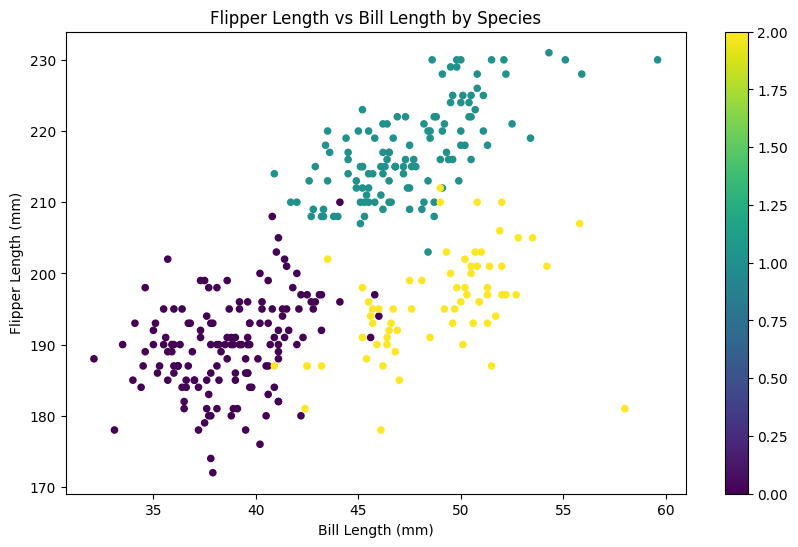

In [46]:
import matplotlib.pyplot as plt
species_codes, _ = pd.factorize(df['species'])
df.plot.scatter(x='bill_length_mm', y='flipper_length_mm', c=species_codes, colormap='viridis', figsize=(10, 6))
plt.title('Flipper Length vs Bill Length by Species')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Flipper Length (mm)')
plt.show()